In [1]:
import pandas as pd
df=pd.read_excel('data.xlsx')
df.head()

,Order_ID,Order_Date,Customer_ID,Customer_Name,Age,Gender,City,Product,Category,Quantity,Unit_Price,Total_Sales
0,ORD100002,2025-02-25,CUST5529,Customer_227,30.0,Female,Bengaluru,Rice,Grocery,7,2829.77,19808.39
1,ORD100003,2025-10-14,CUST3127,Customer_182,63.0,Male,Bengaluru,Book,Education,5,27906.16,139530.80
2,ORD100004,2025-05-13,CUST8887,Customer_487,62.0,Female,Bengaluru,Book,Education,8,37491.06,299928.48
3,ORD100005,2025-12-02,CUST2515,Customer_470,65.0,Female,Kolkata,Mobile,Electronics,9,28541.36,256872.24
4,ORD100006,2025-11-20,CUST4796,Customer_380,44.0,Male,Bengaluru,Rice,Grocery,10,14036.59,140365.90


In [2]:
df.info

<bound method DataFrame.info of       Order_ID  Order_Date Customer_ID Customer_Name   Age  Gender       City  \
0    ORD100002  2025-02-25    CUST5529  Customer_227  30.0  Female  Bengaluru   
1    ORD100003  2025-10-14    CUST3127  Customer_182  63.0    Male  Bengaluru   
2    ORD100004  2025-05-13    CUST8887  Customer_487  62.0  Female  Bengaluru   
3    ORD100005  2025-12-02    CUST2515  Customer_470  65.0  Female    Kolkata   
4    ORD100006  2025-11-20    CUST4796  Customer_380  44.0    Male  Bengaluru   
..         ...         ...         ...           ...   ...     ...        ...   
995  ORD100997  2025-11-07    CUST6410  Customer_301  61.0    Male       Gaya   
996  ORD100998  2025-09-03    CUST7618  Customer_154  25.0    Male       Gaya   
997  ORD100999  2025-09-30    CUST9544  Customer_140  62.0  Female  Hyderabad   
998  ORD101000  2025-02-21    CUST9501  Customer_241   NaN    Male      Delhi   
999  ORD101001  2025-04-23    CUST2714   Customer_98  58.0  Female       Gaya

In [3]:
df.isnull().sum()

Order_ID          0
Order_Date        0
Customer_ID       0
Customer_Name     0
Age              20
Gender            0
City             13
Product           0
Category          0
Quantity          0
Unit_Price        0
Total_Sales       0
dtype: int64

In [4]:
print("Total Sales:",df['Total_Sales'].sum())
print("Average Sales:",df['Total_Sales'].mean())
print("Maximum Sales:",df['Total_Sales'].max())

Total Sales: 139399439.65
Average Sales: 139399.43965000001
Maximum Sales: 493677.5


In [5]:
df.groupby('Category')['Total_Sales'].sum().sort_values(ascending=False)

Category
Electronics    50778581.70
Education      25031689.40
Grocery        22231711.28
Furniture      21521561.48
Fashion        19835895.79
Name: Total_Sales, dtype: float64

In [6]:
df.groupby('City')['Total_Sales'].sum().sort_values(ascending=False).head(10)

City
Patna        19285966.89
Kolkata      18884349.57
Bengaluru    18773574.32
Mumbai       18757050.17
Hyderabad    17166766.87
Delhi        16097079.00
Pune         14513175.90
Gaya         14380859.39
Name: Total_Sales, dtype: float64

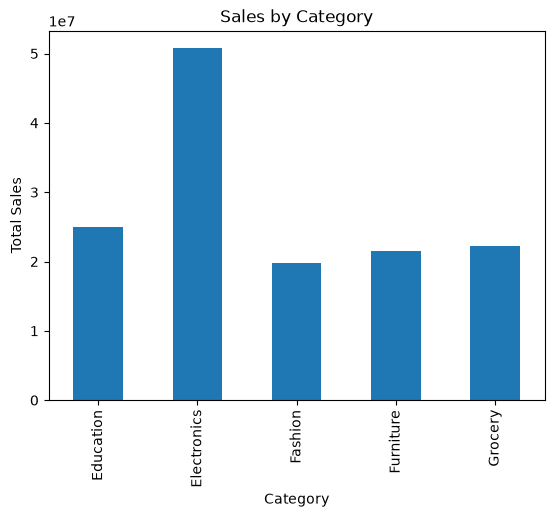

In [7]:
import matplotlib.pyplot as plt

df.groupby('Category')['Total_Sales'].sum().plot(kind='bar')
plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")
plt.show()

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Order_ID       1000 non-null   str    
 1   Order_Date     1000 non-null   str    
 2   Customer_ID    1000 non-null   str    
 3   Customer_Name  1000 non-null   str    
 4   Age            980 non-null    float64
 5   Gender         1000 non-null   str    
 6   City           987 non-null    str    
 7   Product        1000 non-null   str    
 8   Category       1000 non-null   str    
 9   Quantity       1000 non-null   int64  
 10  Unit_Price     1000 non-null   float64
 11  Total_Sales    1000 non-null   float64
dtypes: float64(3), int64(1), str(8)
memory usage: 93.9 KB


In [9]:
df.describe()

,Age,Quantity,Unit_Price,Total_Sales
count,980.000000,1000.000000,1000.000000,1000.000000
mean,41.360204,5.435000,25486.783410,139399.439650
std,13.822597,2.838632,14179.402361,114100.051546
min,18.000000,1.000000,145.780000,437.340000
25%,30.000000,3.000000,13895.722500,47066.632500
50%,41.000000,5.000000,25398.740000,108594.025000
75%,54.000000,8.000000,37512.382500,203722.882500
max,65.000000,10.000000,49997.530000,493677.500000


In [10]:
df["Age"] = df["Age"].fillna(df["Age"].median())
df["City"] = df["City"].fillna(df["City"].mode()[0])

df.isnull().sum()

Order_ID         0
Order_Date       0
Customer_ID      0
Customer_Name    0
Age              0
Gender           0
City             0
Product          0
Category         0
Quantity         0
Unit_Price       0
Total_Sales      0
dtype: int64

In [11]:
df.to_excel("Cleaned_Dataset.xlsx", index=False)